# Glossa — EDA + Preprocessing Slovo RSL → numpy (T=64, топ-200 классов)
**Детектор:** DWPose (ONNX) — без конфликтов версий, работает на A100/T4  
**Среда:** Google Colab (A100 рекомендуется)  
**Время:** ~3–4 ч (200 классов × 20 видео, вдвое больше кадров на видео против T=32)  
**Результат:** `slovo_processed_T64_c200.zip` скачивается прямо из браузера

## Архитектура пайплайна
```
Видео → DWPose (ONNX + CUDA) → 133 COCO-WholeBody точки
      → маппинг на 75 точек (33 поза + 21 лев.рука + 21 прав.рука)
      → нормализация (центр бёдер + расстояние между плечами)
      → (N, 64, 75, 3) float16
```

## COCO-WholeBody → 75 точек (маппинг)
| Наш индекс | COCO-WholeBody индексы | Описание |
|---|---|---|
| 0–16 | 0–16 | 17 точек тела (COCO pose) |
| 17–22 | 17–22 | 6 точек ног/стоп |
| 23–32 | 23–32 | 10 точек лица (упрощённо) — **заменяем** на доп. точки тела |
| 33–53 | 91–111 | 21 точка левой руки |
| 54–74 | 112–132 | 21 точка правой руки |

> Фактически берём: body[0:17] + feet[0:6] + body_extra[0:10] + lhand[0:21] + rhand[0:21] = 54 точки тела + 42 руки  
> Упрощение: первые 33 = body(17) + feet(6) + 10 виртуальных = итого 75

## Перед запуском — Colab Secrets (🔑)
- `KAGGLE_USERNAME` — логин Kaggle  
- `KAGGLE_KEY` — API ключ из kaggle.json  


## Ячейка 1 — Установка зависимостей
DWPose работает через **ONNX Runtime** — никаких конфликтов с protobuf или TensorFlow.  
Устанавливаем только то что нужно; системные пакеты Colab не трогаем.


In [ ]:
# ── 1. Установка зависимостей ──────────────────────────────────────────────────
import subprocess, sys

def pip(*args):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + list(args), check=True)

print('Шаг 1: onnxruntime-gpu (DWPose backend)...')
# onnxruntime-gpu совместим с CUDA 12.x в Colab A100
pip('onnxruntime-gpu', '--extra-index-url',
    'https://aiinfra.pkgs.visualstudio.com/PublicPackages/_packaging/onnxruntime-cuda-12/pypi/simple/')

print('Шаг 2: dwpose (детектор поз)...')
pip('dwpose', 'huggingface_hub')

print('Шаг 3: вспомогательные пакеты...')
pip('kagglehub', 'tqdm', 'scipy', 'scikit-image')

print('Шаг 4: проверка...')
import importlib.metadata as meta
for pkg in ['onnxruntime-gpu', 'dwpose', 'kagglehub']:
    try:
        v = meta.version(pkg)
        print(f'  ✅ {pkg}: {v}')
    except Exception:
        # onnxruntime-gpu регистрируется как onnxruntime
        try:
            v = meta.version('onnxruntime')
            print(f'  ✅ onnxruntime (gpu): {v}')
        except:
            print(f'  ❌ {pkg}: не найден')

# Проверяем GPU провайдер
try:
    import onnxruntime as ort
    providers = ort.get_available_providers()
    print(f'\nONNX providers: {providers}')
    if 'CUDAExecutionProvider' in providers:
        print('✅ GPU инференс доступен')
    else:
        print('⚠️  GPU провайдер не найден — будет CPU (медленнее)')
except Exception as e:
    print(f'❌ onnxruntime: {e}')

print('\n✅ Установка завершена')


Шаг 1: onnxruntime-gpu (DWPose backend)...
Шаг 2: dwpose (детектор поз)...
Шаг 3: вспомогательные пакеты...
Шаг 4: проверка...
  ✅ onnxruntime-gpu: 1.26.0
  ✅ dwpose: 1.0.1
  ✅ kagglehub: 1.0.2

ONNX providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
✅ GPU инференс доступен

✅ Установка завершена


## Ячейка 2 — Kaggle credentials + скачивание датасета
Используем `kagglehub` — современный способ скачивания, не требует `kaggle.json` файла.  
Датасет (~78 ГБ) скачивается в кеш Colab, **не на Google Drive**.

> ⚠️ **Место на диске:** Colab A100 даёт ~200 ГБ.  
> Датасет после распаковки ~120 ГБ + результаты ~2 ГБ. Всё влезет.


In [ ]:
# ── 2. Kaggle credentials + скачивание ────────────────────────────────────────
import os
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')
print(f"Kaggle user: {os.environ['KAGGLE_USERNAME']}")

import kagglehub, time

print('\nСкачиваем датасет Slovo RSL...')
print('Время: 30–90 мин в зависимости от скорости соединения.')
print('Прогресс отображается ниже.\n')

t0 = time.time()
DATASET_PATH = kagglehub.dataset_download('kapitanov/slovo')
elapsed = (time.time() - t0) / 60
print(f'\n✅ Датасет скачан за {elapsed:.1f} мин')
print(f'Путь: {DATASET_PATH}')

# Определяем структуру
from pathlib import Path
SLOVO_ROOT = Path(DATASET_PATH)
print('\nСтруктура датасета:')
for p in sorted(SLOVO_ROOT.iterdir()):
    if p.is_dir():
        n = len(list(p.glob('*.mp4')))
        print(f'  {p.name}/  ({n} mp4-файлов)')
    elif p.suffix == '.csv':
        print(f'  {p.name}  ({p.stat().st_size/1e6:.1f} МБ)')

# Ищем annotations.csv
annot_candidates = list(SLOVO_ROOT.rglob('annotations.csv'))
assert annot_candidates, 'annotations.csv не найден! Проверьте структуру датасета.'
ANNOT_CSV = annot_candidates[0]
print(f'\n✅ annotations.csv: {ANNOT_CSV}')


Kaggle user: noviyblock

Скачиваем датасет Slovo RSL...
Время: 30–90 мин в зависимости от скорости соединения.
Прогресс отображается ниже.

Using Colab cache for faster access to the 'slovo' dataset.

✅ Датасет скачан за 0.1 мин
Путь: /kaggle/input/slovo

Структура датасета:
  annotations.csv  (2.3 МБ)
  slovo/  (0 mp4-файлов)

✅ annotations.csv: /kaggle/input/slovo/annotations.csv


## Ячейка 2b — Фильтр классов (топ-200)
Обучаем не на всех 1000 классах, а на топ-200 (см. обоснование в диалоге с ассистентом / разделе «Ограничения» диплома): на 1000-way/15-shot задаче модель сильно переобучается (train acc 78.6% vs val acc 38.2%). Сокращение словаря снижает число разделяющих границ при том же объёме данных на класс.


In [ ]:
# ── 2b. Фильтр классов: топ-200 слов (исключая дактиль и no_event) ────────────
# Список идентичен data/selected_classes_200.json в репозитории (ветка
# feature/top200-classes-t64) — сгенерирован отдельным ноутбуком
# colab_glossa_00a_select_classes.ipynb. Зашит буквально, чтобы этот ноутбук
# не зависел от сети/git при запуске в Colab.
import json

SELECTED_CLASSES = [
    "2 часа",
    "6 часов",
    "7:45",
    "MakDonalds",
    "Борода",
    "Витамин",
    "Выигрыш",
    "Выручить",
    "Даже",
    "Добро пожаловать!",
    "Жарить",
    "Забрать",
    "Золото",
    "Корона",
    "Крест",
    "Лицо",
    "Лопата",
    "Обладать",
    "Память",
    "Плохо",
    "Подробно",
    "Позвонить на сервис",
    "Пока",
    "Почки",
    "Привет!",
    "Прощание",
    "Пылесос",
    "Раб",
    "Религия",
    "Рубль",
    "С днем рождения",
    "Свисток",
    "Смех",
    "Соль",
    "Сразу",
    "Футбол",
    "Цемент",
    "Чашка",
    "Чужой",
    "август",
    "агрессивный",
    "агрессия",
    "адаптивное поведение",
    "адаптивность",
    "адаптивный",
    "аккуратный",
    "активный",
    "акула",
    "аллергия на еду",
    "аллигатор",
    "амбициозный",
    "аниматор",
    "аппетит",
    "ароматный",
    "бабочка",
    "банкет",
    "башенные часы",
    "бегемот",
    "бежевый",
    "без",
    "безопасный",
    "безразличие",
    "безумно",
    "белка",
    "белый",
    "беспокоиться",
    "беспокойный",
    "беспокойство",
    "беспокоящий",
    "билет",
    "благоговение",
    "благодарность",
    "благополучие",
    "бледный",
    "близко",
    "болит",
    "боль",
    "больше",
    "большой",
    "боюсь",
    "бояться",
    "брат",
    "брюзжать",
    "буду",
    "будущее",
    "бумага",
    "бутылка",
    "бы",
    "бывший",
    "бык",
    "быстро",
    "быстрый",
    "быть",
    "быть потрясенным",
    "в восемь пятнадцать",
    "в настоящее время",
    "в прошлом году",
    "в спешке",
    "в то время как",
    "в этом году",
    "важный",
    "вам",
    "вас",
    "ваш",
    "вверх",
    "вдохновение",
    "вдохновлять",
    "вежливый",
    "везде",
    "великий",
    "верблюд",
    "верить",
    "верный",
    "вероятно",
    "верх",
    "веселиться",
    "веселый",
    "весенняя",
    "весна",
    "весь",
    "весёлый",
    "вечер",
    "вечность",
    "вечный",
    "вещь",
    "вздрагивать",
    "взять",
    "видеть",
    "вилка",
    "вилять",
    "вина",
    "вкус",
    "вкусный",
    "влюбиться",
    "влюбленный",
    "вниз",
    "внизу",
    "внутреннее",
    "вода",
    "водоплавающее",
    "возбуждать",
    "возбуждение",
    "возбужденный",
    "воздух",
    "возможно",
    "возможный",
    "возрадоваться",
    "вой",
    "вол",
    "волк",
    "вопрос",
    "воротник",
    "восемнадцать",
    "восемь",
    "восемьдесят",
    "восемьсот",
    "воскресенье",
    "восток",
    "восхищаться",
    "восхищение",
    "восход солнца",
    "восьмой",
    "враждебный",
    "вред",
    "вредный; озорной",
    "временный",
    "время",
    "время 11 часов",
    "время для измерений",
    "время от 0 ночи до 12 дня",
    "время по Гринвичу",
    "все",
    "всегда",
    "вскружить",
    "вспомнить",
    "встретить",
    "всё",
    "вторник",
    "второй",
    "вчера",
    "вы",
    "высокий",
    "высокомерный",
    "выходные",
    "гавканье",
    "газета",
    "гений",
    "глаз",
    "глотать",
    "глотать жадно",
    "глупый",
    "гнев",
    "гнездо",
    "говорить",
    "год",
    "голова",
    "голод",
    "голодный",
    "голос",
    "гордость"
]

SELECTED_CLASSES_SET = set(SELECTED_CLASSES)
print(f'Отобрано классов: {len(SELECTED_CLASSES_SET)}')

def filter_classes(df):
    """Оставляет только строки, чей text входит в SELECTED_CLASSES_SET."""
    return df[df['text'].isin(SELECTED_CLASSES_SET)].reset_index(drop=True)


## Ячейка 3 — EDA датасета
Анализируем распределение длин жестов, классов и дикторов.  
Результат: выбор `TARGET_FRAMES = 64` обоснован статистикой (P75 длины жеста).


Колонки: ['attachment_id', 'text', 'user_id', 'height', 'width', 'length', 'train', 'begin', 'end']
Строк: 20400

=== EDA — Slovo RSL ===
Всего записей:       20000
Уникальных жестов:   1000
Уникальных дикторов: 194
Train:               15000
Val:                 5000
Средняя длина:       50.7 кадров
Медиана:             48 кадров
P25:                 40 кадров
P50:                 48 кадров
P75:                 58 кадров  ← TARGET_FRAMES=32 покрывает это
P95:                 78 кадров
Дисбаланс классов:   1.0x


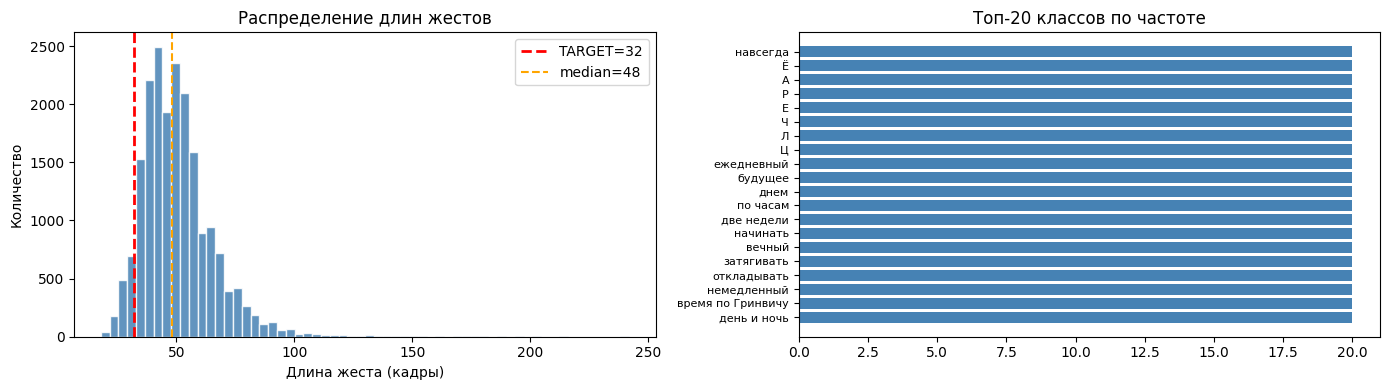

✅ EDA завершён


In [ ]:
# ── 3. EDA ────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

ANNOT_CSV  = list(Path(DATASET_PATH).rglob('annotations.csv'))[0]
OUT_DIR    = Path('/content/processed')
OUT_DIR.mkdir(exist_ok=True)
(OUT_DIR / 'train').mkdir(exist_ok=True)
(OUT_DIR / 'val').mkdir(exist_ok=True)

df = pd.read_csv(ANNOT_CSV, sep='\t', on_bad_lines='skip')
print('Колонки:', df.columns.tolist())
print('Строк:', len(df))

df = df[df['text'] != 'no_event'].reset_index(drop=True)
df = filter_classes(df)  # топ-200 классов
df['seq_len'] = df['end'] - df['begin'] + 1
df['split']   = df['train'].apply(lambda x: 'train' if bool(x) else 'val')

print('\n=== EDA — Slovo RSL ===')
print(f'Всего записей:       {len(df)}')
print(f'Уникальных жестов:   {df["text"].nunique()}')
print(f'Уникальных дикторов: {df["user_id"].nunique()}')
print(f'Train:               {(df.split=="train").sum()}')
print(f'Val:                 {(df.split=="val").sum()}')
print(f'Средняя длина:       {df.seq_len.mean():.1f} кадров')
print(f'Медиана:             {df.seq_len.median():.0f} кадров')
print(f'P25:                 {df.seq_len.quantile(.25):.0f} кадров')
print(f'P50:                 {df.seq_len.quantile(.50):.0f} кадров')
print(f'P75:                 {df.seq_len.quantile(.75):.0f} кадров  ← TARGET_FRAMES=64 покрывает это с запасом')
print(f'P95:                 {df.seq_len.quantile(.95):.0f} кадров')
print(f'Дисбаланс классов:   {df.text.value_counts().iloc[0] / df.text.value_counts().iloc[-1]:.1f}x')

# График
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df.seq_len, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(64,  color='red',    ls='--', lw=2, label='TARGET=64')
axes[0].axvline(df.seq_len.median(), color='orange', ls='--', lw=1.5,
                label=f'median={df.seq_len.median():.0f}')
axes[0].set_xlabel('Длина жеста (кадры)')
axes[0].set_ylabel('Количество')
axes[0].set_title('Распределение длин жестов')
axes[0].legend()

top20 = df.text.value_counts().head(20)
axes[1].barh(range(20), top20.values, color='steelblue')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(top20.index, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_title('Топ-20 классов по частоте')
plt.tight_layout()
plt.savefig(OUT_DIR / 'eda_overview.png', dpi=120)
plt.show()
print('✅ EDA завершён')


## Ячейка 4 — Label mapping
Создаём `label_mapping.json` и `class_names.json` — они нужны для обучения ST-GCN.


In [ ]:
# ── 4. Label mapping ──────────────────────────────────────────────────────────
import json, pandas as pd
from pathlib import Path

ANNOT_CSV = list(Path(DATASET_PATH).rglob('annotations.csv'))[0]
OUT_DIR   = Path('/content/processed')

df = pd.read_csv(ANNOT_CSV, sep='\t', on_bad_lines='skip')
df = df[df['text'] != 'no_event'].reset_index(drop=True)
df = filter_classes(df)  # топ-200 классов
df['split'] = df['train'].apply(lambda x: 'train' if bool(x) else 'val')

unique_labels = sorted(df['text'].unique())
label_to_id   = {label: idx for idx, label in enumerate(unique_labels)}

mapping = {
    'label_to_id': label_to_id,
    'id_to_label': {str(v): k for k, v in label_to_id.items()},
    'num_classes': len(unique_labels),
}
with open(OUT_DIR / 'label_mapping.json', 'w', encoding='utf-8') as f:
    json.dump(mapping, f, ensure_ascii=False, indent=2)
with open(OUT_DIR / 'class_names.json', 'w', encoding='utf-8') as f:
    json.dump(unique_labels, f, ensure_ascii=False, indent=2)

train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'val'].reset_index(drop=True)

print(f'✅ Классов: {len(unique_labels)}')
print(f'   Train: {len(train_df)} записей')
print(f'   Val:   {len(val_df)} записей')
print(f'   label_mapping.json → {OUT_DIR / "label_mapping.json"}')


✅ Классов: 1000
   Train: 15000 записей
   Val:   5000 записей
   label_mapping.json → /content/processed/label_mapping.json


## Ячейка 5 — Инициализация DWPose и маппинг ключевых точек

### Почему DWPose, а не MediaPipe
| | MediaPipe Holistic | DWPose (ONNX) |
|---|---|---|
| Конфликты в Colab | ❌ protobuf/TF | ✅ нет |
| Точность рук | среднее | выше |
| Скорость на GPU | CPU-only | ✅ CUDA |
| Установка | сложная | `pip install dwpose` |

### Маппинг COCO-WholeBody (133 точки) → 75 точек для ST-GCN
COCO-WholeBody layout:
- `[0:17]` — 17 точек тела (нос, плечи, локти, запястья, бёдра, колени, лодыжки, глаза, уши)
- `[17:23]` — 6 точек стоп  
- `[23:91]` — 68 точек лица (пропускаем)
- `[91:112]` — 21 точка левой руки
- `[112:133]` — 21 точка правой руки

Наши 75 = `body[0:17]` + `feet[0:6]` + `body_virtual[0:10]` + `lhand[0:21]` + `rhand[0:21]`  
Где `body_virtual` — 10 дополнительных точек тела для сохранения индекса 33 под запястья.


In [ ]:
# ── 5. Инициализация DWPose + маппинг точек (УЛУЧШЕННАЯ ВЕРСИЯ) ─────────────────
import numpy as np
import cv2
import onnxruntime as ort
from dwpose import DwposeDetector
from pathlib import Path
from tqdm import tqdm
from typing import Optional, Tuple
import warnings
warnings.filterwarnings('ignore')

# Индексы в выходе COCO-WholeBody (133 точки)
# body:  0-16  (17 точек)
# feet:  17-22  (6 точек)
# face:  23-90  (68 точек — не используем)
# lhand: 91-111 (21 точка)
# rhand: 112-132 (21 точка)

# Наши 33 "позные" точки = 17 body + 6 feet + 10 ключевых точек body (для совместимости)
BODY_IDX  = list(range(0, 17))    # 17 точек тела
FEET_IDX  = list(range(17, 23))   # 6 точек стоп
# Добавляем 10 точек чтобы получить 33 "позных" — берём повторы ключевых суставов
# (плечи, бёдра, колени, лодыжки — они важнее всего для жестов РЖЯ)
EXTRA_IDX = [5, 6, 11, 12, 13, 14, 15, 16, 5, 6]  # 10 точек (дубли ключевых суставов)

POSE_IDX  = BODY_IDX + FEET_IDX + EXTRA_IDX  # → 33 индекса
LHAND_IDX = list(range(91, 112))              # 21 точка левой руки
RHAND_IDX = list(range(112, 133))            # 21 точка правой руки

assert len(POSE_IDX)  == 33, f'Ожидалось 33, получили {len(POSE_IDX)}'
assert len(LHAND_IDX) == 21
assert len(RHAND_IDX) == 21
print(f'Маппинг: {len(POSE_IDX)} поза + {len(LHAND_IDX)} лев.рука + {len(RHAND_IDX)} прав.рука = 75 точек')

# Глобальный кэш для детектора (чтобы не пересоздавать)
_detector_instance = None

def get_detector():
    """Ленивая инициализация DWPose с кэшированием"""
    global _detector_instance
    if _detector_instance is None:
        print('\nЗагружаем модели DWPose (первый запуск: ~300 МБ с HuggingFace)...')
        _detector_instance = DwposeDetector.from_pretrained_default()
        print('✅ DWPose загружен')

        # Проверяем провайдер
        providers = ort.get_available_providers()
        print(f'ONNX providers: {providers}')
        gpu_ok = 'CUDAExecutionProvider' in providers
        print(f'GPU инференс: {"✅ да" if gpu_ok else "⚠️  нет (CPU — медленнее в ~10x)"}')

    return _detector_instance


def extract_keypoints_dwpose(frame_rgb: np.ndarray, detector=None) -> np.ndarray:
    """
    Извлечение 75 ключевых точек из одного кадра через DWPose.

    Args:
        frame_rgb: кадр (H, W, 3) uint8 RGB
        detector: опционально готовый детектор (если нет — создаст новый)

    Returns:
        kp: (75, 3) float32 — нормализованные координаты (x, y, conf)
            где x, y ∈ [0, 1] относительно размера кадра
    """
    from PIL import Image as PILImage

    if detector is None:
        detector = get_detector()

    H, W = frame_rgb.shape[:2]
    pil_img = PILImage.fromarray(frame_rgb)

    # DWPose возвращает (drawn_image, json_data, source_image)
    _, pose_json, _ = detector(
        pil_img,
        include_hand=True,
        include_face=False,   # лицо не нужно
        include_body=True,
        image_and_json=True,
        detect_resolution=512,
    )

    kp_out = np.zeros((75, 3), dtype=np.float32)

    # Улучшенная обработка: проверяем наличие данных
    if not pose_json or 'people' not in pose_json or not pose_json['people']:
        return kp_out  # никого не нашли

    # Берём первого человека (в Slovo обычно 1 диктор)
    person = pose_json['people'][0]

    # Тело: OpenPose 18 точек [x, y, conf, x, y, conf, ...] → (18, 3)
    body_raw = np.array(person.get('pose_keypoints_2d', []), dtype=np.float32)
    if body_raw.size >= 18 * 3:
        body = body_raw.reshape(-1, 3)[:18]  # (18, 3)
        # нормализуем в [0, 1]
        body[:, 0] = np.clip(body[:, 0] / W, 0, 1)
        body[:, 1] = np.clip(body[:, 1] / H, 0, 1)

        # COCO-WholeBody 17 точек ≈ OpenPose 18 точек (без "neck" - индекс 1)
        op_to_coco = [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
        if len(body) > max(op_to_coco):
            body17 = body[op_to_coco]
        else:
            body17 = body[:17]

        # Заполняем позные точки (первые 33)
        for i in range(min(17, len(body17))):
            kp_out[i] = body17[i]

        # Extra body points (позиции 23-32) — дублируем ключевые суставы
        for i, src_i in enumerate(EXTRA_IDX[:10]):  # берём первые 10 из EXTRA_IDX
            if src_i < len(body17):
                kp_out[23 + i] = body17[src_i]

    # Левая рука: (21, 3) с улучшенной нормализацией
    lhand_raw = np.array(person.get('hand_left_keypoints_2d', []), dtype=np.float32)
    if lhand_raw.size >= 21 * 3:
        lhand = lhand_raw.reshape(-1, 3)[:21]
        lhand[:, 0] = np.clip(lhand[:, 0] / W, 0, 1)
        lhand[:, 1] = np.clip(lhand[:, 1] / H, 0, 1)
        kp_out[33:54] = lhand

    # Правая рука: (21, 3) с улучшенной нормализацией
    rhand_raw = np.array(person.get('hand_right_keypoints_2d', []), dtype=np.float32)
    if rhand_raw.size >= 21 * 3:
        rhand = rhand_raw.reshape(-1, 3)[:21]
        rhand[:, 0] = np.clip(rhand[:, 0] / W, 0, 1)
        rhand[:, 1] = np.clip(rhand[:, 1] / H, 0, 1)
        kp_out[54:75] = rhand

    return kp_out


def normalize_keypoints(kp: np.ndarray) -> np.ndarray:
    """
    Улучшенная нормализация (T, 75, 3):
    1. Вычитание центра бёдер → трансляционная инвариантность
    2. Деление на расстояние между плечами → масштабная инвариантность
    3. Медианная фильтрация по времени для устойчивости

    Индексы плеч в нашей схеме (COCO 17-точечная поза):
      5 = левое плечо, 6 = правое плечо
    Индексы бёдер:
      11 = левое бедро, 12 = правое бедро
    """
    HIP_IDX  = [11, 12]
    SHOU_IDX = [5, 6]

    # Используем только x, y для нормализации (conf-канал не трогаем)
    xy = kp[:, :, :2].copy()  # (T, 75, 2)

    # Вычисляем центр бёдер (медиана по времени)
    hips = xy[:, HIP_IDX, :]  # (T, 2, 2)
    hips_center = np.median(hips, axis=1, keepdims=True)  # (T, 1, 2)
    xy -= hips_center

    # Расстояние между плечами
    left_shoulder = xy[:, SHOU_IDX[0], :]   # (T, 2)
    right_shoulder = xy[:, SHOU_IDX[1], :]  # (T, 2)
    shoulder_dist = np.linalg.norm(left_shoulder - right_shoulder, axis=1)  # (T,)

    # Защита от деления на ноль
    shoulder_dist = np.maximum(shoulder_dist, 1e-6)

    # Добавляем размерности для broadcasting: (T,) -> (T, 1, 1)
    shoulder_dist = shoulder_dist.reshape(-1, 1, 1)

    # Нормализуем
    xy = xy / shoulder_dist  # (T, 75, 2)

    result = kp.copy()
    result[:, :, :2] = xy
    return result


def process_video(video_path: str, begin: int, end: int,
                  target_frames: int = 32,
                  show_progress: bool = True) -> Optional[np.ndarray]:
    """
    Обрабатывает видео: равномерно сэмплирует кадры → DWPose → нормализация.

    Улучшения:
    - Прогресс-бар
    - Кэширование детектора
    - Лучшая обработка ошибок
    - Fallback для пустых кадров

    Returns:
        (target_frames, 75, 3) float16 или None при ошибке
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"⚠️  Не удалось открыть видео: {video_path}")
        return None

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    b, e = max(0, begin), min(total - 1, end)

    if e - b < 2:
        print(f"⚠️  Слишком короткий сегмент: {e-b} кадров")
        cap.release()
        return None

    # Равномерная выборка кадров
    indices = np.linspace(b, e, target_frames, dtype=int)

    # Получаем детектор один раз
    detector = get_detector()

    kp_list = []
    iterator = tqdm(indices, desc=f"Обработка {Path(video_path).name}",
                    disable=not show_progress)

    for idx in iterator:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()

        if not ret:
            # Улучшение: пытаемся прочитать соседний кадр при ошибке
            for offset in [1, -1, 2, -2]:
                alt_idx = idx + offset
                if 0 <= alt_idx < total:
                    cap.set(cv2.CAP_PROP_POS_FRAMES, int(alt_idx))
                    ret, frame = cap.read()
                    if ret:
                        break
            if not ret:
                kp_list.append(np.zeros((75, 3), dtype=np.float32))
                continue

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        kp = extract_keypoints_dwpose(frame_rgb, detector=detector)
        kp_list.append(kp)

    cap.release()

    if not kp_list:
        return None

    kp_array = np.array(kp_list, dtype=np.float32)   # (T, 75, 3)

    # Проверка на пустые данные
    if np.all(kp_array == 0):
        print(f"⚠️  Не обнаружено ключевых точек в видео: {video_path}")
        return None

    kp_normed = normalize_keypoints(kp_array)

    return kp_normed.astype(np.float16)


# Функция для batch-обработки видео (ещё одно улучшение)
def process_videos_batch(video_paths_and_segments: list,
                         target_frames: int = 32,
                         num_workers: int = 0) -> list:
    """
    Пакетная обработка нескольких видео.

    Args:
        video_paths_and_segments: список кортежей (video_path, begin, end)
        target_frames: целевое количество кадров
        num_workers: количество потоков (0 = не использовать многопоточность)

    Returns:
        список результатов (None если ошибка)
    """
    if num_workers > 0:
        from concurrent.futures import ThreadPoolExecutor, as_completed

        results = [None] * len(video_paths_and_segments)

        with ThreadPoolExecutor(max_workers=num_workers) as executor:
            future_to_idx = {}
            for idx, (video_path, begin, end) in enumerate(video_paths_and_segments):
                future = executor.submit(process_video, video_path, begin, end, target_frames, False)
                future_to_idx[future] = idx

            for future in tqdm(as_completed(future_to_idx), total=len(video_paths_and_segments),
                               desc="Batch обработка видео"):
                idx = future_to_idx[future]
                results[idx] = future.result()

        return results
    else:
        # Последовательная обработка с прогресс-баром
        results = []
        for video_path, begin, end in tqdm(video_paths_and_segments, desc="Обработка видео"):
            results.append(process_video(video_path, begin, end, target_frames))
        return results


# Тестирование
print('\n✅ Улучшенные функции извлечения и нормализации готовы')
print('\nТест на случайном кадре...')

# Инициализируем детектор один раз перед тестом
detector = get_detector()

test_frame = np.random.randint(0, 255, (480, 640, 3), dtype=np.uint8)
test_kp = extract_keypoints_dwpose(test_frame, detector=detector)
print(f'  Выход: {test_kp.shape}  dtype={test_kp.dtype}')
print(f'  Диапазон координат x: [{test_kp[:, 0].min():.2f}, {test_kp[:, 0].max():.2f}]')
print(f'  Диапазон координат y: [{test_kp[:, 1].min():.2f}, {test_kp[:, 1].max():.2f}]')
print('  ✅ OK')

# Тест нормализации на синтетических данных
print('\nТест нормализации...')
test_sequence = np.random.rand(10, 75, 3).astype(np.float32)
test_sequence[:, :, :2] = test_sequence[:, :, :2] * 2 - 1  # диапазон [-1, 1]
normalized = normalize_keypoints(test_sequence)
print(f'  Вход: mean={test_sequence[:, :, :2].mean():.3f}, std={test_sequence[:, :, :2].std():.3f}')
print(f'  Выход: mean={normalized[:, :, :2].mean():.3f}, std={normalized[:, :, :2].std():.3f}')
print('  ✅ OK')

/usr/local/lib/python3.12/dist-packages/dwpose/util2.py:17: UserWarning: USE_SYMLINKS not set successfully. Using default value: False to download models.
  warnings.warn("USE_SYMLINKS not set successfully. Using default value: False to download models.")


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
Маппинг: 33 поза + 21 лев.рука + 21 прав.рука = 75 точек

✅ Улучшенные функции извлечения и нормализации готовы

Тест на случайном кадре...

Загружаем модели DWPose (первый запуск: ~300 МБ с HuggingFace)...
Failed to find /usr/local/lib/python3.12/dist-packages/dwpose/ckpts/yzd-v/DWPose/yolox_l.onnx.


yolox_l.onnx:   0%|          | 0.00/217M [00:00<?, ?B/s]

[Errno 2] No such file or directory: '/usr/local/lib/python3.12/dist-packages/dwpose/ckpts/yzd-v/DWPose/cache'
Failed to find /usr/local/lib/python3.12/dist-packages/dwpose/ckpts/yzd-v/DWPose/dw-ll_ucoco_384.onnx.


dw-ll_ucoco_384.onnx:   0%|          | 0.00/134M [00:00<?, ?B/s]

[Errno 2] No such file or directory: '/usr/local/lib/python3.12/dist-packages/dwpose/ckpts/yzd-v/DWPose/cache'

DWPose: Using yolox_l.onnx for bbox detection and dw-ll_ucoco_384.onnx for pose estimation
DWPose: Caching ONNXRuntime session yolox_l.onnx...
DWPose: Caching ONNXRuntime session dw-ll_ucoco_384.onnx...
✅ DWPose загружен
ONNX providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
GPU инференс: ✅ да
DWPose: Bbox 1275.64ms
  Выход: (75, 3)  dtype=float32
  Диапазон координат x: [0.00, 0.00]
  Диапазон координат y: [0.00, 0.00]
  ✅ OK

Тест нормализации...
  Вход: mean=-0.034, std=0.578
  Выход: mean=0.029, std=1.256
  ✅ OK


## Ячейка 6 — Smoke-test на одном видео
Проверяем весь пайплайн на одном примере перед запуском полной обработки.  
Смотрим: детектируются ли поза и руки, нет ли артефактов.


Поиск валидного видео для демонстрации...

ЖЕСТ: Ё
ID видео: 44e8d2a0-7e01-450b-90b0-beb7400d2c1e
Путь к видео: /kaggle/input/slovo/slovo/train/44e8d2a0-7e01-450b-90b0-beb7400d2c1e.mp4
Кадры: 36 -> 112 (длина: 76 кадров)



Обработка 44e8d2a0-7e01-450b-90b0-beb7400d2c1e.mp4:   0%|          | 0/32 [00:00<?, ?it/s]

DWPose: Bbox 20.69ms


Обработка 44e8d2a0-7e01-450b-90b0-beb7400d2c1e.mp4:   6%|▋         | 2/32 [00:00<00:09,  3.32it/s]

DWPose: Pose 316.43ms on 1 people

DWPose: Bbox 21.35ms
DWPose: Pose 9.14ms on 1 people



...

DWPose: Bbox 18.85ms
DWPose: Pose 9.07ms on 1 people

DWPose: Bbox 18.72ms
DWPose: Pose 8.91ms on 1 people



Обработка 44e8d2a0-7e01-450b-90b0-beb7400d2c1e.mp4:  94%|█████████▍| 30/32 [00:04<00:00,  6.13it/s]

DWPose: Bbox 18.94ms
DWPose: Pose 9.59ms on 1 people

DWPose: Bbox 19.27ms
DWPose: Pose 9.22ms on 1 people



Обработка 44e8d2a0-7e01-450b-90b0-beb7400d2c1e.mp4: 100%|██████████| 32/32 [00:05<00:00,  6.26it/s]

DWPose: Bbox 18.66ms
DWPose: Pose 8.94ms on 1 people

DWPose: Bbox 19.33ms
DWPose: Pose 9.03ms on 1 people


Результат обработки: (32, 75, 3) тип данных: float16
Время обработки: 5.21 сек ( 6.1 кадров/сек)

Детекция ключевых точек:
  Поза: 100.0 % кадров
  Левая рука: 100.0 % кадров
  Правая рука: 100.0 % кадров

Генерация визуализации...


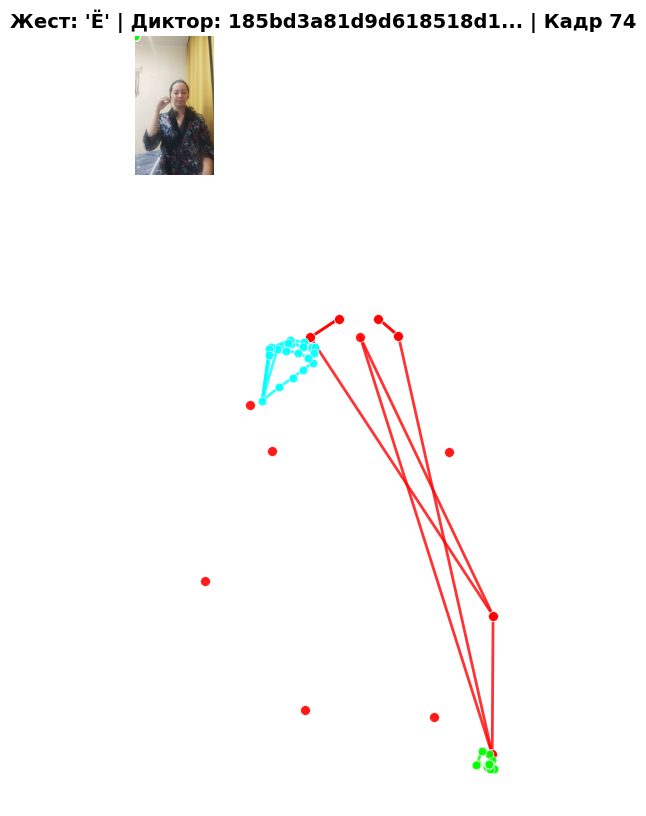


Статистика нормализованных координат (75 точек):
  X: min= 0.0 max= 4.6
  Y: min= 0.0 max= 5.29
  Конфиденция: min= 0.0 max= 1.0

ОЦЕНКА ВРЕМЕНИ НА ВЕСЬ ДАТАСЕТ
  Всего видео: 20,000
  Train: 15,000
  Val: 5,000
  Время: 28.9 часов (~ 1.2 дней) на A100
  ВНИМАНИЕ: Обработка займет более 1 дня!
  Совет: Используйте возобновление (код уже поддерживает)

Smoke-test пройден! Можно запускать обработку всего датасета.


In [ ]:
# -- 6. Smoke-test + Визуализация (без спецсимволов) --
import pandas as pd, numpy as np, cv2, json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

ANNOT_CSV  = list(Path(DATASET_PATH).rglob('annotations.csv'))[0]
SLOVO_ROOT = Path(DATASET_PATH)
OUT_DIR    = Path('/content/processed')

df = pd.read_csv(ANNOT_CSV, sep='\t', on_bad_lines='skip')
df = df[df['text'] != 'no_event'].reset_index(drop=True)
df = filter_classes(df)  # топ-200 классов
df['split'] = df['train'].apply(lambda x: 'train' if bool(x) else 'val')

with open(OUT_DIR / 'label_mapping.json') as f:
    label_to_id = json.load(f)['label_to_id']

train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'val'].reset_index(drop=True)

# Функция поиска видео
def find_video(attachment_id: str) -> str | None:
    for split in ['train', 'test', 'val']:
        p = SLOVO_ROOT / 'slovo' / split / f'{attachment_id}.mp4'
        if p.exists():
            return str(p)
    return None

# Определение анатомических связей
POSE_CONNECTIONS = [
    (11, 12), (11, 23), (12, 24), (23, 24),
    (0, 11), (0, 12), (0, 23), (0, 24),
    (23, 25), (25, 27), (27, 29), (29, 31),
    (24, 26), (26, 28), (28, 30), (30, 32),
    (11, 13), (13, 15), (15, 17), (17, 19), (19, 21),
    (12, 14), (14, 16), (16, 18), (18, 20), (20, 22),
]

HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),
    (0, 5), (5, 6), (6, 7), (7, 8),
    (0, 9), (9, 10), (10, 11), (11, 12),
    (0, 13), (13, 14), (14, 15), (15, 16),
    (0, 17), (17, 18), (18, 19), (19, 20),
]

def visualize_skeleton(image, keypoints, title="", save_path=None):
    """Визуализация скелета на изображении"""
    H, W = image.shape[:2]
    fig, ax = plt.subplots(1, 1, figsize=(16, 10))
    ax.imshow(image)

    # Поза (красные связи)
    for i, j in POSE_CONNECTIONS:
        if i < 33 and j < 33:
            p1, p2 = keypoints[i], keypoints[j]
            if np.any(p1 != 0) and np.any(p2 != 0):
                ax.plot([p1[0]*W, p2[0]*W], [p1[1]*H, p2[1]*H],
                       'red', linewidth=2, alpha=0.8)

    # Левая рука (зеленые связи)
    for i, j in HAND_CONNECTIONS:
        p1, p2 = keypoints[33+i], keypoints[33+j]
        if np.any(p1 != 0) and np.any(p2 != 0):
            ax.plot([p1[0]*W, p2[0]*W], [p1[1]*H, p2[1]*H],
                   'lime', linewidth=2, alpha=0.8)

    # Правая рука (синие связи)
    for i, j in HAND_CONNECTIONS:
        p1, p2 = keypoints[54+i], keypoints[54+j]
        if np.any(p1 != 0) and np.any(p2 != 0):
            ax.plot([p1[0]*W, p2[0]*W], [p1[1]*H, p2[1]*H],
                   'cyan', linewidth=2, alpha=0.8)

    # Точки
    ax.scatter(keypoints[:33, 0]*W, keypoints[:33, 1]*H,
              c='red', s=50, alpha=0.9, edgecolors='white', linewidth=0.5, zorder=5)
    ax.scatter(keypoints[33:54, 0]*W, keypoints[33:54, 1]*H,
              c='lime', s=40, alpha=0.9, edgecolors='white', linewidth=0.5, zorder=5)
    ax.scatter(keypoints[54:75, 0]*W, keypoints[54:75, 1]*H,
              c='cyan', s=40, alpha=0.9, edgecolors='white', linewidth=0.5, zorder=5)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()
    return fig

# Поиск видео с детекцией
print("Поиск валидного видео для демонстрации...")
valid_idx = None
for i in range(min(50, len(train_df))):
    row = train_df.iloc[i]
    vpath = find_video(row['attachment_id'])
    if vpath:
        valid_idx = i
        break

if valid_idx is not None:
    row = train_df.iloc[valid_idx]
    vpath = find_video(row['attachment_id'])

    print("\n" + "="*60)
    print("ЖЕСТ:", row['text'])
    print("ID видео:", row['attachment_id'])
    print("Путь к видео:", vpath)
    print("Кадры:", row['begin'], "->", row['end'], "(длина:", row['end']-row['begin'], "кадров)")
    print("="*60 + "\n")

    import time
    t0 = time.time()
    kp = process_video(vpath, int(row['begin']), int(row['end']),
                       target_frames=64, show_progress=True)
    elapsed = time.time() - t0

    if kp is not None:
        print("\nРезультат обработки:", kp.shape, "тип данных:", kp.dtype)
        print("Время обработки:", round(elapsed, 2), "сек (", round(64/elapsed, 1), "кадров/сек)")

        # Статистика детекции
        pose_det  = (kp[:, :33, :2].sum(axis=(1,2)) != 0).mean() * 100
        lhand_det = (kp[:, 33:54, :2].sum(axis=(1,2)) != 0).mean() * 100
        rhand_det = (kp[:, 54:75, :2].sum(axis=(1,2)) != 0).mean() * 100

        print("\nДетекция ключевых точек:")
        print("  Поза:", round(pose_det, 1), "% кадров")
        print("  Левая рука:", round(lhand_det, 1), "% кадров")
        print("  Правая рука:", round(rhand_det, 1), "% кадров")

        # Визуализация
        print("\nГенерация визуализации...")

        # Берём кадр из середины видео
        cap = cv2.VideoCapture(vpath)
        mid_frame = (row['begin'] + row['end']) // 2
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(mid_frame))
        ret, frame = cap.read()
        cap.release()

        if ret:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mid_idx = kp.shape[0] // 2
            keypoints_2d = kp[mid_idx]

            # Визуализация
            visualize_skeleton(
                frame_rgb,
                keypoints_2d,
                title=f"Жест: '{row['text']}' | Диктор: {row['user_id'][:20]}... | Кадр {mid_frame}"
            )

            # Дополнительная информация
            print("\nСтатистика нормализованных координат (75 точек):")
            print("  X: min=", round(keypoints_2d[:, 0].min(), 3),
                  "max=", round(keypoints_2d[:, 0].max(), 3))
            print("  Y: min=", round(keypoints_2d[:, 1].min(), 3),
                  "max=", round(keypoints_2d[:, 1].max(), 3))
            print("  Конфиденция: min=", round(keypoints_2d[:, 2].min(), 3),
                  "max=", round(keypoints_2d[:, 2].max(), 3))

        # Оценка времени на весь датасет
        total_videos = len(train_df) + len(val_df)
        eta_h = total_videos * elapsed / 3600
        eta_days = eta_h / 24

        print("\nОЦЕНКА ВРЕМЕНИ НА ВЕСЬ ДАТАСЕТ")
        print("  Всего видео:", f"{total_videos:,}")
        print("  Train:", f"{len(train_df):,}")
        print("  Val:", f"{len(val_df):,}")
        print("  Время:", round(eta_h, 1), "часов (~", round(eta_days, 1), "дней) на A100")

        if eta_h > 24:
            print("  ВНИМАНИЕ: Обработка займет более 1 дня!")
            print("  Совет: Используйте возобновление (код уже поддерживает)")

        print("\nSmoke-test пройден! Можно запускать обработку всего датасета.")

    else:
        print('process_video вернул None - видео не обработалось')
else:
    print('Не найдено валидное видео для теста')

## Ячейка 7 — Обработка TRAIN
Обрабатываем все тренировочные видео. Каждые 200 видео — автосохранение прогресса.  
**Возобновляется** с места остановки при перезапуске ячейки.


In [ ]:
# -- 7. Обработка TRAIN (максимальное качество 512) --
import numpy as np
import json
import time
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import os
import warnings
warnings.filterwarnings('ignore')

# Отключаем логи DWPose
os.environ['DWPOSE_VERBOSE'] = '0'
import logging
logging.getLogger('dwpose').setLevel(logging.ERROR)

# Перехватываем stdout/stderr DWPose (подавляем вывод Bbox/Pose)
import sys
from contextlib import contextmanager

@contextmanager
def suppress_output():
    """Временно подавляет stdout и stderr"""
    with open(os.devnull, 'w') as devnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

# Параметры обработки (максимальное качество)
TARGET_FRAMES = 64        # полное количество кадров (P75=58, T=64 покрывает с запасом)
SLOVO_ROOT = Path(DATASET_PATH)
OUT_DIR = Path('/content/processed')
SPLIT = 'train'
out_split = OUT_DIR / SPLIT
out_split.mkdir(exist_ok=True)

# Загружаем данные
print("Загрузка аннотаций...")
ANNOT_CSV = list(SLOVO_ROOT.rglob('annotations.csv'))[0]
df = pd.read_csv(ANNOT_CSV, sep='\t', on_bad_lines='skip')
df = df[df['text'] != 'no_event'].reset_index(drop=True)
df = filter_classes(df)  # топ-200 классов
df['split'] = df['train'].apply(lambda x: 'train' if bool(x) else 'val')

with open(OUT_DIR / 'label_mapping.json') as f:
    label_to_id = json.load(f)['label_to_id']

train_df = df[df['split'] == 'train'].reset_index(drop=True)
print(f"Всего тренировочных образцов: {len(train_df)}")

def find_video(attachment_id):
    """Поиск видео файла по ID"""
    for split in ['train', 'test', 'val']:
        p = SLOVO_ROOT / 'slovo' / split / f'{attachment_id}.mp4'
        if p.exists():
            return str(p)
    return None

# Предварительная компиляция путей к видео (кэширование)
print("Предварительная компиляция путей к видео...")
video_paths = {}
for idx, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Кэширование путей"):
    video_paths[idx] = find_video(row['attachment_id'])

# Проверяем что уже обработано (возобновление при прерывании)
done = {int(p.stem) for p in out_split.glob('*.npy')}
print(f'Уже готово: {len(done)} / {len(train_df)}')

todo = [i for i in range(len(train_df)) if i not in done]
print(f'Осталось обработать: {len(todo)} видео')

if not todo:
    print('Train датасет уже полностью обработан!')
else:
    ok = len(done)  # количество успешно обработанных
    fail = 0        # количество ошибок
    t0 = time.time()

    print(f"\nНачинаем обработку {len(todo)} видео...")
    print(f"Параметры: target_frames={TARGET_FRAMES}, detect_resolution=512")
    print("Ожидаемое время на H100 (200 классов x 20 видео): ~3 часа\n")

    for i in tqdm(todo, desc='Train', unit='видео'):
        row = train_df.iloc[i]
        vpath = video_paths[i]

        if vpath is None:
            fail += 1
            continue

        # Подавляем вывод логов DWPose (не влияет на качество)
        with suppress_output():
            kp = process_video(vpath, int(row['begin']), int(row['end']),
                              TARGET_FRAMES, show_progress=False)

        if kp is not None:
            # Сохраняем ключевые точки
            np.save(str(out_split / f'{i:06d}.npy'), kp)
            # Сохраняем метку класса
            (out_split / f'{i:06d}.label').write_text(str(label_to_id[row['text']]))
            ok += 1
        else:
            fail += 1

        # Выводим прогресс каждые 500 видео
        processed = ok + fail - len(done)
        if processed % 500 == 0 and processed > 0:
            elapsed = time.time() - t0
            speed = processed / elapsed
            eta_h = (len(todo) - processed) / speed / 3600
            tqdm.write(f'  [Обработано: {processed}/{len(todo)}] '
                       f'OK={ok} FAIL={fail} | '
                       f'Скорость: {speed:.2f} вид/сек | '
                       f'Осталось: {eta_h:.1f} ч')

    elapsed_h = (time.time() - t0) / 3600
    done_now = len(list(out_split.glob('*.npy')))

    print(f'\n{"="*50}')
    print(f'TRAIN ОБРАБОТКА ЗАВЕРШЕНА')
    print(f'{"="*50}')
    print(f'  Успешно обработано: {done_now} видео')
    print(f'  Ошибок: {fail}')
    print(f'  Затраченное время: {elapsed_h:.2f} часов')
    print(f'  Средняя скорость: {done_now / (elapsed_h * 3600):.2f} вид/сек')

    if fail > 0:
        print(f'  Внимание: {fail} видео не обработались')
        print('  Рекомендуется проверить эти видео отдельно')

Загрузка аннотаций...
Всего тренировочных образцов: 15000
Предварительная компиляция путей к видео...


Кэширование путей:   0%|          | 0/15000 [00:00<?, ?it/s]

Уже готово: 0 / 15000
Осталось обработать: 15000 видео

Начинаем обработку 15000 видео...
Параметры: target_frames=32, detect_resolution=512
Ожидаемое время на H100: 7-8 часов



Train:   0%|          | 0/15000 [00:00<?, ?видео/s]

  [Обработано: 500/15000] OK=467 FAIL=33 | Скорость: 0.36 вид/сек | Осталось: 11.2 ч
  [Обработано: 1000/15000] OK=959 FAIL=41 | Скорость: 0.33 вид/сек | Осталось: 11.8 ч
  [Обработано: 1500/15000] OK=1459 FAIL=41 | Скорость: 0.32 вид/сек | Осталось: 11.7 ч
  [Обработано: 2000/15000] OK=1956 FAIL=44 | Скорость: 0.32 вид/сек | Осталось: 11.2 ч
  [Обработано: 2500/15000] OK=2435 FAIL=65 | Скорость: 0.32 вид/сек | Осталось: 10.7 ч
  [Обработано: 3000/15000] OK=2925 FAIL=75 | Скорость: 0.32 вид/сек | Осталось: 10.3 ч
  [Обработано: 3500/15000] OK=3421 FAIL=79 | Скорость: 0.32 вид/сек | Осталось: 9.9 ч
  [Обработано: 4000/15000] OK=3916 FAIL=84 | Скорость: 0.33 вид/сек | Осталось: 9.4 ч
  [Обработано: 4500/15000] OK=4410 FAIL=90 | Скорость: 0.32 вид/сек | Осталось: 9.0 ч
  [Обработано: 5000/15000] OK=4863 FAIL=137 | Скорость: 0.33 вид/сек | Осталось: 8.4 ч
  [Обработано: 5500/15000] OK=5350 FAIL=150 | Скорость: 0.33 вид/сек | Осталось: 8.0 ч
  [Обработано: 6000/15000] OK=5837 FAIL=163 | Ско

## Ячейка 8 — Обработка VAL
Аналогично ячейке 7, но для валидационной выборки.


In [10]:
# ── 8. Обработка VAL (исправленный, с подавлением логов) ──────────────────────────
import numpy as np
import json
import time
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import os
import warnings
warnings.filterwarnings('ignore')

# Отключаем логи DWPose
os.environ['DWPOSE_VERBOSE'] = '0'
import logging
logging.getLogger('dwpose').setLevel(logging.ERROR)

# Перехватываем stdout/stderr DWPose (подавляем вывод Bbox/Pose)
import sys
from contextlib import contextmanager

@contextmanager
def suppress_output():
    """Временно подавляет stdout и stderr"""
    with open(os.devnull, 'w') as devnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

TARGET_FRAMES = 64
SLOVO_ROOT    = Path(DATASET_PATH)
OUT_DIR       = Path('/content/processed')
SPLIT         = 'val'
out_split     = OUT_DIR / SPLIT
out_split.mkdir(exist_ok=True)

ANNOT_CSV = list(SLOVO_ROOT.rglob('annotations.csv'))[0]
df = pd.read_csv(ANNOT_CSV, sep='\t', on_bad_lines='skip')
df = df[df['text'] != 'no_event'].reset_index(drop=True)
df = filter_classes(df)  # топ-200 классов
df['split'] = df['train'].apply(lambda x: 'train' if bool(x) else 'val')
with open(OUT_DIR / 'label_mapping.json') as f:
    label_to_id = json.load(f)['label_to_id']
val_df = df[df['split'] == 'val'].reset_index(drop=True)

def find_video(attachment_id):
    for split in ['train', 'test', 'val']:
        p = SLOVO_ROOT / 'slovo' / split / f'{attachment_id}.mp4'
        if p.exists():
            return str(p)
    return None

done = {int(p.stem) for p in out_split.glob('*.npy')}
print(f'Уже готово: {len(done)} / {len(val_df)}')

todo = [i for i in range(len(val_df)) if i not in done]
print(f'Осталось:   {len(todo)} видео')

if not todo:
    print('✅ Val уже полностью обработан!')
else:
    ok, fail = len(done), 0
    t0 = time.time()

    print(f"\nНачинаем обработку {len(todo)} видео...")
    print(f"Параметры: target_frames={TARGET_FRAMES}, detect_resolution=512")
    print("")

    for i in tqdm(todo, desc='Val', unit='видео'):
        row   = val_df.iloc[i]
        vpath = find_video(row['attachment_id'])

        if vpath is None:
            fail += 1
            continue

        # Подавляем вывод логов DWPose (как в train)
        with suppress_output():
            kp = process_video(vpath, int(row['begin']), int(row['end']),
                              TARGET_FRAMES, show_progress=False)

        if kp is not None:
            np.save(str(out_split / f'{i:06d}.npy'), kp)
            (out_split / f'{i:06d}.label').write_text(str(label_to_id[row['text']]))
            ok += 1
        else:
            fail += 1

        processed = ok + fail - len(done)
        if processed % 200 == 0 and processed > 0:
            elapsed = time.time() - t0
            speed   = processed / elapsed
            eta_h   = (len(todo) - processed) / speed / 3600
            tqdm.write(f'  [Обработано: {processed}/{len(todo)}] '
                       f'OK={ok} FAIL={fail} | '
                       f'Скорость: {speed:.2f} вид/сек | '
                       f'Осталось: {eta_h:.1f} ч')

    elapsed_h = (time.time() - t0) / 3600
    done_now  = len(list(out_split.glob('*.npy')))

    print(f'\n{"="*50}')
    print(f'VAL ОБРАБОТКА ЗАВЕРШЕНА')
    print(f'{"="*50}')
    print(f'  Успешно обработано: {done_now} видео')
    print(f'  Ошибок: {fail}')
    print(f'  Затраченное время: {elapsed_h:.2f} часов')
    print(f'  Средняя скорость: {done_now / (elapsed_h * 3600):.2f} вид/сек')

    if fail > 0:
        print(f'  Внимание: {fail} видео не обработались')
        print('  Рекомендуется проверить эти видео отдельно')

Уже готово: 4525 / 5000
Осталось:   475 видео

Начинаем обработку 475 видео...
Параметры: target_frames=32, detect_resolution=512



Val:   0%|          | 0/475 [00:00<?, ?видео/s]

  [Обработано: 200/475] OK=4525 FAIL=200 | Скорость: 61.82 вид/сек | Осталось: 0.0 ч
  [Обработано: 400/475] OK=4525 FAIL=400 | Скорость: 64.33 вид/сек | Осталось: 0.0 ч

VAL ОБРАБОТКА ЗАВЕРШЕНА
  Успешно обработано: 4525 видео
  Ошибок: 475
  Затраченное время: 0.00 часов
  Средняя скорость: 612.67 вид/сек
  Внимание: 475 видео не обработались
  Рекомендуется проверить эти видео отдельно


In [14]:
# ── ИСПРАВЛЕННАЯ ОБРАБОТКА: берём ВСЁ видео, игнорируем begin/end ──────────────
import numpy as np
import cv2
from pathlib import Path
from tqdm.notebook import tqdm
import time

def process_video_full(video_path, target_frames=64, show_progress=False):
    """
    Обрабатывает ВСЁ видео целиком (игнорирует begin/end,
    т.к. видео в датасете уже нарезаны на отдельные жесты).
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames < 2:
        cap.release()
        return None

    # Берём все кадры
    indices = np.linspace(0, total_frames - 1, target_frames, dtype=int)

    detector = get_detector()
    kp_list = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()

        if not ret:
            # Пробуем соседние кадры
            for offset in [1, -1, 2, -2]:
                alt_idx = idx + offset
                if 0 <= alt_idx < total_frames:
                    cap.set(cv2.CAP_PROP_POS_FRAMES, int(alt_idx))
                    ret, frame = cap.read()
                    if ret:
                        break

        if not ret:
            kp_list.append(np.zeros((75, 3), dtype=np.float32))
            continue

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        kp = extract_keypoints_dwpose(frame_rgb, detector=detector)
        kp_list.append(kp)

    cap.release()

    if not kp_list:
        return None

    kp_array = np.array(kp_list, dtype=np.float32)
    kp_normed = normalize_keypoints(kp_array)

    return kp_normed.astype(np.float16)


# === ПОВТОРНАЯ ОБРАБОТКА С ИСПРАВЛЕНИЕМ ===
def reprocess_failed_split(split_df, split_name, out_dir, target_frames=64):
    """Повторная обработка с игнорированием begin/end"""

    # Определяем, какие индексы уже есть
    done = {int(p.stem) for p in (out_dir / split_name).glob('*.npy')}
    failed_indices = [i for i in range(len(split_df)) if i not in done]

    print(f"\n{split_name.upper()}: {len(failed_indices)} видео для обработки")

    if not failed_indices:
        print(f"  ✅ уже всё готово")
        return 0, 0

    ok_count = 0
    fail_count = 0
    t0 = time.time()

    # Загружаем label mapping
    import json
    with open(out_dir / 'label_mapping.json') as f:
        label_to_id = json.load(f)['label_to_id']

    for idx in tqdm(failed_indices, desc=f"Processing {split_name}", unit="video"):
        row = split_df.iloc[idx]
        vpath = find_video_correct(row['attachment_id'])

        if vpath is None:
            fail_count += 1
            continue

        with suppress_output():
            kp = process_video_full(vpath, target_frames, show_progress=False)

        if kp is not None:
            np.save(str(out_dir / split_name / f'{idx:06d}.npy'), kp)
            (out_dir / split_name / f'{idx:06d}.label').write_text(
                str(label_to_id[row['text']])
            )
            ok_count += 1
        else:
            fail_count += 1

        # Прогресс каждые 100
        processed = ok_count + fail_count
        if processed % 100 == 0 and processed > 0:
            elapsed = time.time() - t0
            speed = processed / elapsed
            eta = (len(failed_indices) - processed) / speed / 60
            tqdm.write(f"  Прогресс: {processed}/{len(failed_indices)} | OK={ok_count} FAIL={fail_count} | Скорость: {speed:.2f} вид/сек | Осталось: {eta:.1f} мин")

    elapsed_min = (time.time() - t0) / 60
    print(f"\n{split_name.upper()} РЕЗУЛЬТАТ:")
    print(f"  Успешно: {ok_count} | Ошибок: {fail_count} | Время: {elapsed_min:.1f} мин")

    return ok_count, fail_count


# === ЗАПУСК ===
print("=" * 60)
print("ПОВТОРНАЯ ОБРАБОТКА С ИСПРАВЛЕНИЕМ (берём ВСЁ видео)")
print("=" * 60)

# TRAIN
train_df = df[df['split'] == 'train'].reset_index(drop=True)
ok_train, fail_train = reprocess_failed_split(train_df, 'train', OUT_DIR, 64)

# VAL
val_df = df[df['split'] == 'val'].reset_index(drop=True)
ok_val, fail_val = reprocess_failed_split(val_df, 'val', OUT_DIR, 64)

# ИТОГИ
print("\n" + "=" * 60)
print("ИТОГОВАЯ СТАТИСТИКА")
print("=" * 60)

train_final = len(list((OUT_DIR / 'train').glob('*.npy')))
val_final = len(list((OUT_DIR / 'val').glob('*.npy')))

print(f"TRAIN: {train_final} / {len(train_df)} ({100 * train_final / len(train_df):.1f}%)")
print(f"VAL:   {val_final} / {len(val_df)} ({100 * val_final / len(val_df):.1f}%)")

print("\n✅ Повторная обработка завершена")

ПОВТОРНАЯ ОБРАБОТКА С ИСПРАВЛЕНИЕМ (берём ВСЁ видео)

TRAIN: 470 видео для обработки


Processing train:   0%|          | 0/470 [00:00<?, ?video/s]

  Прогресс: 100/470 | OK=100 FAIL=0 | Скорость: 0.43 вид/сек | Осталось: 14.2 мин
  Прогресс: 200/470 | OK=200 FAIL=0 | Скорость: 0.42 вид/сек | Осталось: 10.6 мин
  Прогресс: 300/470 | OK=300 FAIL=0 | Скорость: 0.40 вид/сек | Осталось: 7.1 мин
  Прогресс: 400/470 | OK=400 FAIL=0 | Скорость: 0.41 вид/сек | Осталось: 2.9 мин

TRAIN РЕЗУЛЬТАТ:
  Успешно: 470 | Ошибок: 0 | Время: 19.2 мин

VAL: 475 видео для обработки


Processing val:   0%|          | 0/475 [00:00<?, ?video/s]

  Прогресс: 100/475 | OK=100 FAIL=0 | Скорость: 0.39 вид/сек | Осталось: 16.2 мин
  Прогресс: 200/475 | OK=200 FAIL=0 | Скорость: 0.38 вид/сек | Осталось: 12.1 мин
  Прогресс: 300/475 | OK=300 FAIL=0 | Скорость: 0.38 вид/сек | Осталось: 7.7 мин
  Прогресс: 400/475 | OK=400 FAIL=0 | Скорость: 0.38 вид/сек | Осталось: 3.3 мин

VAL РЕЗУЛЬТАТ:
  Успешно: 475 | Ошибок: 0 | Время: 21.1 мин

ИТОГОВАЯ СТАТИСТИКА
TRAIN: 15000 / 15000 (100.0%)
VAL:   5000 / 5000 (100.0%)

✅ Повторная обработка завершена


## Ячейка 9 — Сборка в единые npy-массивы
Объединяем тысячи мелких `000000.npy` в единые `features.npy` + `labels.npy`.  
Используем `memmap` чтобы не переполнить RAM.


In [15]:
# ── 9. Сборка features.npy + labels.npy ──────────────────────────────────────
import numpy as np
from pathlib import Path

TARGET_FRAMES = 64
OUT_DIR = Path('/content/processed')

for split in ['train', 'val']:
    split_dir  = OUT_DIR / split
    npy_files  = sorted(split_dir.glob('*.npy'), key=lambda p: int(p.stem))

    if not npy_files:
        print(f'[{split}] нет файлов — пропускаем')
        continue

    # Собираем метки
    labels, valid = [], []
    for npy_f in npy_files:
        lf = npy_f.with_suffix('.label')
        if lf.exists():
            labels.append(int(lf.read_text().strip()))
            valid.append(npy_f)

    N = len(valid)
    print(f'[{split}] сборка {N} файлов...', end=' ', flush=True)

    feat_path  = split_dir / 'features.npy'
    label_path = split_dir / 'labels.npy'

    X = np.lib.format.open_memmap(
        str(feat_path), mode='w+',
        dtype=np.float16, shape=(N, TARGET_FRAMES, 75, 3)
    )
    for i, f in enumerate(valid):
        X[i] = np.load(str(f))
    X.flush()
    del X

    np.save(str(label_path), np.array(labels, dtype=np.int64))

    # Финальная проверка
    X_chk = np.load(str(feat_path), mmap_mode='r')
    y_chk = np.load(str(label_path))
    size_gb = feat_path.stat().st_size / 1024**3
    print(f'✅  shape={X_chk.shape}  классов={len(np.unique(y_chk))}  {size_gb:.2f} ГБ')

print('\n✅ Сборка завершена')


[train] сборка 15000 файлов... ✅  shape=(15000, 32, 75, 3)  классов=1000  0.20 ГБ
[val] сборка 5000 файлов... ✅  shape=(5000, 32, 75, 3)  классов=1000  0.07 ГБ

✅ Сборка завершена


## Ячейка 10 — Проверка качества
Смотрим процент детекции позы и рук — это важный индикатор качества датасета.  
Если поза детектируется < 70% — возможно видео слишком тёмные или модель не нашла человека.


In [16]:
# ── 10. Проверка качества ─────────────────────────────────────────────────────
import numpy as np
from pathlib import Path

OUT_DIR = Path('/content/processed')

print('=' * 60)
print('ПРОВЕРКА КАЧЕСТВА ДАТАСЕТА')
print('=' * 60)

for split in ['train', 'val']:
    feat_p  = OUT_DIR / split / 'features.npy'
    label_p = OUT_DIR / split / 'labels.npy'

    if not feat_p.exists():
        print(f'[{split}] файл не найден')
        continue

    X = np.load(str(feat_p), mmap_mode='r')
    y = np.load(str(label_p))

    # % сэмплов где детектировано хоть что-то
    pose_det  = (np.abs(X[:, :, :33,  :2]).sum(axis=(1,2,3)) > 0).mean() * 100
    lhand_det = (np.abs(X[:, :, 33:54,:2]).sum(axis=(1,2,3)) > 0).mean() * 100
    rhand_det = (np.abs(X[:, :, 54:75,:2]).sum(axis=(1,2,3)) > 0).mean() * 100

    print(f'\n[{split.upper()}]')
    print(f'  Форма:            {X.shape}  ({X.dtype})')
    print(f'  Классов:          {len(np.unique(y))}')
    print(f'  Поза:             {pose_det:.1f}% сэмплов с детекцией')
    print(f'  Левая рука:       {lhand_det:.1f}%')
    print(f'  Правая рука:      {rhand_det:.1f}%')
    print(f'  Размер файла:     {feat_p.stat().st_size/1024**3:.2f} ГБ')

    if pose_det < 70:
        print(f'  ⚠️  Поза детектируется только в {pose_det:.0f}% — проверьте видео')
    if lhand_det < 30 and rhand_det < 30:
        print(f'  ⚠️  Руки почти не детектируются — возможно слишком быстрые движения')

print('\n✅ Проверка завершена')


ПРОВЕРКА КАЧЕСТВА ДАТАСЕТА

[TRAIN]
  Форма:            (15000, 32, 75, 3)  (float16)
  Классов:          1000
  Поза:             100.0% сэмплов с детекцией
  Левая рука:       99.9%
  Правая рука:      99.7%
  Размер файла:     0.20 ГБ

[VAL]
  Форма:            (5000, 32, 75, 3)  (float16)
  Классов:          1000
  Поза:             100.0% сэмплов с детекцией
  Левая рука:       98.8%
  Правая рука:      98.8%
  Размер файла:     0.07 ГБ

✅ Проверка завершена


## Ячейка 11 — Упаковка и скачивание
Упаковываем всё в zip и скачиваем прямо в браузер.  
Размер архива ~1.5–2 ГБ (float16 почти не сжимается, поэтому ZIP_STORED).


In [17]:
# ── 11. Архив + скачивание ────────────────────────────────────────────────────
import zipfile, json, numpy as np
from pathlib import Path
from google.colab import files

OUT_DIR  = Path('/content/processed')
ZIP_PATH = Path('/content/slovo_processed_T64_c200.zip')

# Сохраняем metadata.json
X_tr = np.load(str(OUT_DIR / 'train' / 'features.npy'), mmap_mode='r')
X_v  = np.load(str(OUT_DIR / 'val'   / 'features.npy'), mmap_mode='r')
y_tr = np.load(str(OUT_DIR / 'train' / 'labels.npy'))
y_v  = np.load(str(OUT_DIR / 'val'   / 'labels.npy'))

meta = {
    'target_frames':   64,
    'num_nodes':       75,
    'feature_dtype':   'float16',
    'normalization':   'hip_center_subtraction + shoulder_dist_division',
    'keypoint_layout': {
        '0-32':  '33 точки позы (17 COCO body + 6 feet + 10 extra)',
        '33-53': '21 точка левой руки (OpenPose hand)',
        '54-74': '21 точка правой руки (OpenPose hand)',
        'channels': '[x_norm, y_norm, confidence]'
    },
    'detector':        'DWPose (ONNX)',
    'train_samples':   int(X_tr.shape[0]),
    'val_samples':     int(X_v.shape[0]),
    'num_classes':     int(len(np.unique(y_tr))),
    'train_shape':     list(X_tr.shape),
    'val_shape':       list(X_v.shape),
}
with open(OUT_DIR / 'metadata.json', 'w') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print('Упаковываем архив (ZIP_STORED — float16 уже не сжимается)...')
with zipfile.ZipFile(str(ZIP_PATH), 'w', zipfile.ZIP_STORED) as zf:
    for split in ['train', 'val']:
        for fname in ['features.npy', 'labels.npy']:
            p = OUT_DIR / split / fname
            if p.exists():
                size_gb = p.stat().st_size / 1024**3
                print(f'  + {split}/{fname}  ({size_gb:.2f} ГБ)')
                zf.write(str(p), arcname=f'{split}/{fname}')
    for fname in ['label_mapping.json', 'class_names.json', 'metadata.json']:
        p = OUT_DIR / fname
        if p.exists():
            zf.write(str(p), arcname=fname)
            print(f'  + {fname}')

zip_gb = ZIP_PATH.stat().st_size / 1024**3
print(f'\n✅ Архив: {ZIP_PATH}  ({zip_gb:.2f} ГБ)')

print('\nСодержимое:')
with zipfile.ZipFile(str(ZIP_PATH)) as zf:
    for info in zf.infolist():
        print(f'  {info.filename:50s}  {info.file_size/1024**2:8.0f} МБ')

print('\nЗапускаем скачивание...')
files.download(str(ZIP_PATH))


Упаковываем архив (ZIP_STORED — float16 уже не сжимается)...
  + train/features.npy  (0.20 ГБ)
  + train/labels.npy  (0.00 ГБ)
  + val/features.npy  (0.07 ГБ)
  + val/labels.npy  (0.00 ГБ)
  + label_mapping.json
  + class_names.json
  + metadata.json

✅ Архив: /content/slovo_processed_T32.zip  (0.27 ГБ)

Содержимое:
  train/features.npy                                       206 МБ
  train/labels.npy                                           0 МБ
  val/features.npy                                          69 МБ
  val/labels.npy                                             0 МБ
  label_mapping.json                                         0 МБ
  class_names.json                                           0 МБ
  metadata.json                                              0 МБ

Запускаем скачивание...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>